In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

foldername = '/home/edavenport/analysis/yannai-waves/with_spring_2013/vertical_modes/'

In [98]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['Zl'] = ds_tpose_noTAO.Zl.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['Zl'] = ds_tpose_TAO.Zl.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-29'))

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


### Select Region

In [100]:
hFacC_col

<xarray.DataArray 'hFacC' (Z: 66)> Size: 264B
dask.array<mean_agg-aggregate, shape=(66,), dtype=float32, chunksize=(66,), chunktype=numpy.ndarray>
Coordinates:
  * Z        (Z) float64 528B -1.0 -3.0 -5.0 ... -4.75e+03 -5.25e+03 -5.75e+03
    XC       float64 8B 220.1
    drF      (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    PHrefC   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    rhoRef   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
Attributes:
    standard_name:  cell_vertical_fraction
    long_name:      vertical fraction of open cell

In [102]:
nz_water.values

array(63)

In [103]:
# 1. Select longitude
ds_col = ds_tpose_noTAO.sel(XC=lon, method='nearest')

# 2. Select latitude slice
ds_col = ds_col.sel(YC=slice(lat_min, lat_max))

# 3. Average over YC
ds_mean = ds_col.mean(dim='YC')

# 4. Handle hFacC separately as a column
hFacC_col = ds_col.hFacC.mean(dim='YC')  # dims: (Z)

# Suppose hFacC_col has dims (Z,) and is Dask-backed
wet_idx = (hFacC_col > 0).argmax(dim="Z").compute()  # first wet cell
nz_water = (hFacC_col > 0).sum(dim="Z").compute()    # number of wet cells

In [109]:
# tpose_ds.ADJetan is t, xc, YG
lat_min = -0.1
lat_max = 0.1
lon = 220

ds_tpose_TAO = ds_tpose_TAO.sel(YC=slice(lat_min,lat_max)).sel(XC=lon,method='nearest').mean(dim='YC')
ds_tpose_noTAO = ds_tpose_noTAO.sel(YC=slice(lat_min,lat_max)).sel(XC=lon,method='nearest').mean(dim='YC')

### Mean Stratification Profile

In [110]:
g = 9.81
rho0 = 1025

## TPOSE with TAO 
N2 = -g / rho0 * ds_tpose_TAO.DRHODR
N2.name = "N2"
N2.attrs["units"] = "s^-2"

N2 = N2.interp(Zl=ds.Z)
N2_mean = N2.mean(dim='time')
N2_mean.values[-1] = N2_mean.values[-2] # fix bottom value to avoid NaN
N2_mean = N2_mean.clip(min=1e-7)

## TPOSE with TAO 
N2_noTAO = -g / rho0 * ds_tpose_noTAO.DRHODR
N2_noTAO.name = "N2_noTAO"
N2_noTAO.attrs["units"] = "s^-2"

N2_noTAO = N2_noTAO.interp(Zl=ds.Z)
N2_mean_noTAO = N2_noTAO.mean(dim='time')
N2_mean_noTAO.values[-1] = N2_mean_noTAO.values[-2] # fix bottom value to avoid NaN
N2_mean_noTAO = N2_mean_noTAO.clip(min=1e-7)

In [111]:
# Slice the Z dimension safely
N2_mean_noTAO = N2_mean_noTAO.isel(Z=slice(0, nz_water.values))
N2_mean = N2_mean.isel(Z=slice(0, nz_water.values))

### Vertical Mode Decomposition

In [112]:
import numpy as np
import xarray as xr
from scipy.linalg import eigh


def baroclinic_modes(N2, nmodes=3, zdim="z"):

    z = N2[zdim].values
    N2v = N2.values.copy()

    # ensure increasing z
    if z[1] < z[0]:
        z = z[::-1]
        N2v = N2v[::-1]

    # avoid singularities
    N2v = np.maximum(N2v, 1e-7)

    nz = len(z)

    dz = np.diff(z)

    A = np.zeros((nz, nz))

    invN2 = 1 / N2v

    for i in range(1, nz-1):

        dz_up = z[i+1] - z[i]
        dz_dn = z[i] - z[i-1]

        inv_up = 0.5 * (invN2[i] + invN2[i+1])
        inv_dn = 0.5 * (invN2[i] + invN2[i-1])

        A[i,i-1] =  inv_dn / dz_dn**2
        A[i,i]   = -(inv_up/dz_up**2 + inv_dn/dz_dn**2)
        A[i,i+1] =  inv_up / dz_up**2

    # Neumann BC
    A[0,0] = -1
    A[0,1] = 1
    A[-1,-1] = -1
    A[-1,-2] = 1

    eigvals, eigvecs = eigh(-A)

    eigvals = eigvals[1:nmodes+1]
    eigvecs = eigvecs[:,1:nmodes+1]

    c = 1 / np.sqrt(eigvals)

    modes = xr.DataArray(
        eigvecs,
        coords={zdim: z, "mode": np.arange(1, nmodes+1)},
        dims=(zdim, "mode")
    )

    c = xr.DataArray(
        c,
        coords={"mode": np.arange(1, nmodes+1)},
        dims="mode"
    )

    return modes, c

In [141]:
N2_smooth = (
    N2_mean
    .rolling({"Z":8}, center=True)
    .mean()
    .ffill("Z")
    .bfill("Z")
)

N2_smooth_noTAO = (
    N2_mean_noTAO
    .rolling({"Z":8}, center=True)
    .mean()
    .ffill("Z")
    .bfill("Z")
)

In [142]:
N2_mean = N2_mean.compute()
N2_smooth = N2_smooth.compute()
N2_mean_noTAO = N2_mean_noTAO.compute()
N2_smooth_noTAO = N2_smooth_noTAO.compute()

In [159]:
n_modes = 3
modes, c = baroclinic_modes(N2_smooth, nmodes=n_modes, zdim='Z')
modes_noTAO, c_noTAO = baroclinic_modes(N2_smooth_noTAO, nmodes=n_modes, zdim='Z')

In [160]:
modes = modes / np.sqrt((modes**2).integrate("Z"))
modes_noTAO = modes_noTAO / np.sqrt((modes_noTAO**2).integrate("Z"))

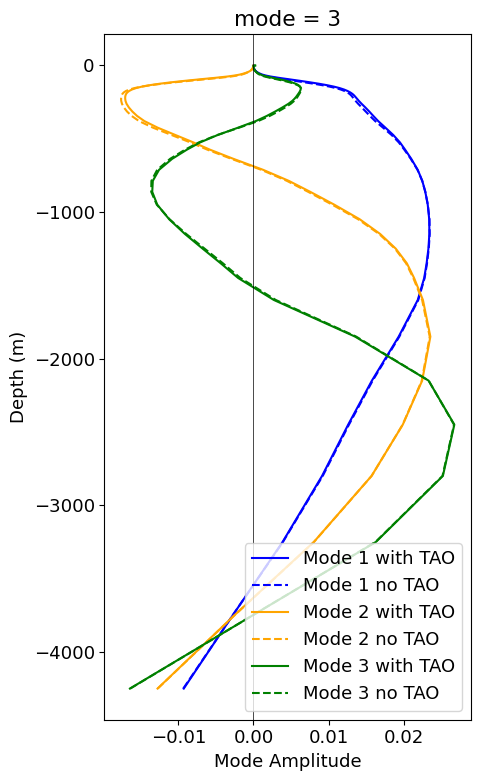

In [161]:
colors = ['blue', 'orange', 'green', 'red']
fig, ax = plt.subplots(figsize=(5,8))
for n in range(1,n_modes+1):
    color = colors[n-1]
    modes.sel(mode=n).plot(ax=ax, y='Z', color=color, label=f'Mode {n} with TAO')
    modes_noTAO.sel(mode=n).plot(ax=ax, y='Z', color=color, label=f'Mode {n} no TAO', linestyle='--')
ax.set_xlabel('Mode Amplitude')
ax.set_ylabel('Depth (m)')
ax.legend(loc='lower right')
ax.axvline(0, color='k', linewidth=0.5)

plt.tight_layout()
fig.savefig(foldername + 'baroclinic_modes_smoothed_normalized.png', dpi=300)

### Look at U Projected Onto Modes

In [164]:
mean_u = ds_tpose_TAO.UVEL.sel(XG=lon, method='nearest').isel(Z=slice(0, nz_water.values)).mean(dim='time')
mean_v = ds_tpose_TAO.VVEL.sel(YG=0.0, method='nearest').isel(Z=slice(0, nz_water.values)).mean(dim='time')

In [166]:
u_proj = (mean_u.values * modes.sel(mode=1)).integrate("Z")
v_prof = (mean_v.values * modes.sel(mode=1)).integrate("Z")

ValueError: operands could not be broadcast together with shapes (66,) (63,) 

In [ ]:
mode_profile_A = u_proj_A.sel(mode=n) * modes.sel(mode=n)
mode_profile_B = u_proj_B.sel(mode=n) * modes.sel(mode=n)

In [ ]:
u = ds_tpose_TAO.UVEL

In [ ]:
# u: (time, lat, lon, Z)
# modes: (Z, mode), normalized
u_proj = (u * modes).integrate("Z")   # (time, lat, lon, mode)

# reconstruct velocity from first 3 modes
u_recon = (u_proj[:, :, :, :3] * modes[:, :3]).sum("mode")

In [ ]:
rho0 = 1025  # kg/m³
KE_mode = 0.5 * rho0 * (u_proj**2 + v_proj**2)

In [ ]:
cluster.close()
client.shutdown()